# Image Denoising using Convolutional Autoencoder on MNIST

### Objective
The aim of this experiment is to build a Convolutional Autoencoder that removes noise from handwritten digit images. Gaussian noise is added to the MNIST dataset, and the model is trained to reconstruct the original clean images.

## Step 1: Import Required Libraries

In this step, the necessary Python libraries are imported.

- **NumPy** is used for numerical operations and generating Gaussian noise.
- **Matplotlib** is used for visualizing images and training graphs.
- **TensorFlow/Keras** provides the MNIST dataset and the deep learning components required to build the autoencoder.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

## Step 2: Load Dataset

Load the MNIST dataset for training and testing.
- Training Images: **60,000**
- Testing Images: **10,000**


In [2]:
(x_train,_),(x_test,_)=mnist.load_data()
print("Training Images:",x_train.shape)
print("Testing Images:",x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


## Step 3: Data Preprocessing

Normalize the pixel values between 0 and 1 and reshape the images so that they can be used as input to the Convolutional Neural Network.

In [3]:
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.

x_train=np.reshape(x_train,(len(x_train),28,28,1))
x_test=np.reshape(x_test,(len(x_test),28,28,1))

## Step 4: Add Gaussian Noise

Artificial Gaussian noise is added to the original images to create noisy input images.

The model receives the noisy images as input and learns to reconstruct the corresponding clean images.

The `noise_factor` controls the intensity of the added noise.

In [4]:
noise_factor=0.5
x_train_noisy=x_train+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_train.shape)
x_test_noisy=x_test+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_test.shape)
x_train_noisy=np.clip(x_train_noisy,0.,1.)
x_test_noisy=np.clip(x_test_noisy,0.,1.)

## Step 5: Visualize Original and Noisy Images

Display a few original and noisy images to observe the effect of the added noise before training the model.

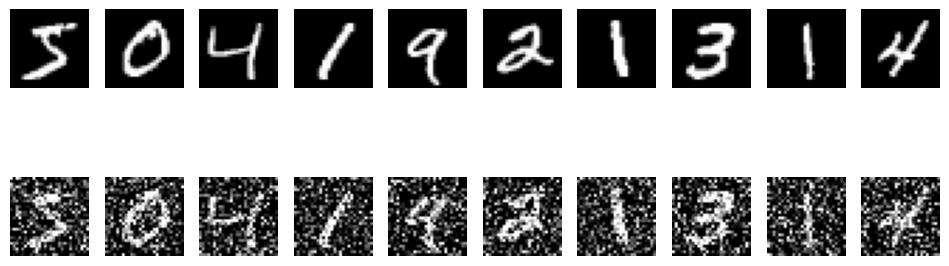

In [5]:
plt.figure(figsize=(12,4))
for i in range(10):
  ax=plt.subplot(2,10,i+1)
  plt.imshow(x_train[i].reshape(28,28),cmap='gray')
  plt.axis('off')

  ax=plt.subplot(2,10,i+11)
  plt.imshow(x_train_noisy[i].reshape(28,28),cmap='gray')
  plt.axis('off')
plt.show()

## Step 6: Build the Convolutional Autoencoder

Build the encoder and decoder using convolution, pooling, and upsampling layers. The encoder extracts important features, while the decoder reconstructs the original image.

In [6]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

## Step 7: Compile the Model

Compile the model using the Adam optimizer and Binary Crossentropy loss before starting the training process.

In [7]:
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Train the Model

Train the autoencoder using noisy images as input and clean images as the target output.

In [8]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 185s 390ms/step - loss: 0.1621 - val_loss: 0.1156
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 189s 403ms/step - loss: 0.1121 - val_loss: 0.1074
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 179s 383ms/step - loss: 0.1066 - val_loss: 0.1040
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 381ms/step - loss: 0.1034 - val_loss: 0.1013
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 177s 378ms/step - loss: 0.1015 - val_loss: 0.1000
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 380ms/step - loss: 0.1002 - val_loss: 0.0989
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 379ms/step - loss: 0.0992 - val_loss: 0.0978
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 379ms/step - loss: 0.0983 - val_loss: 0.0977
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 371ms/step - loss: 0.0976 - val_loss: 0.0969
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 178s 379ms/step - loss: 0.0969 - val_loss: 0.0959


## Step 9: Plot Training and Validation Loss

Plot the training and validation loss to observe how the model performs during training.

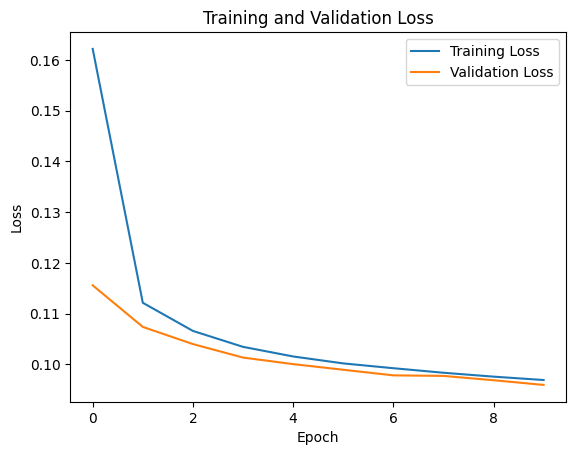

In [12]:
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## Step 10: Generate Denoised Images

Use the trained model to predict clean images from the noisy test images.

In [13]:
decoded_imgs=autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


## Step 11: Compare the Results

Compare the original, noisy, and reconstructed images to evaluate the denoising performance of the model.

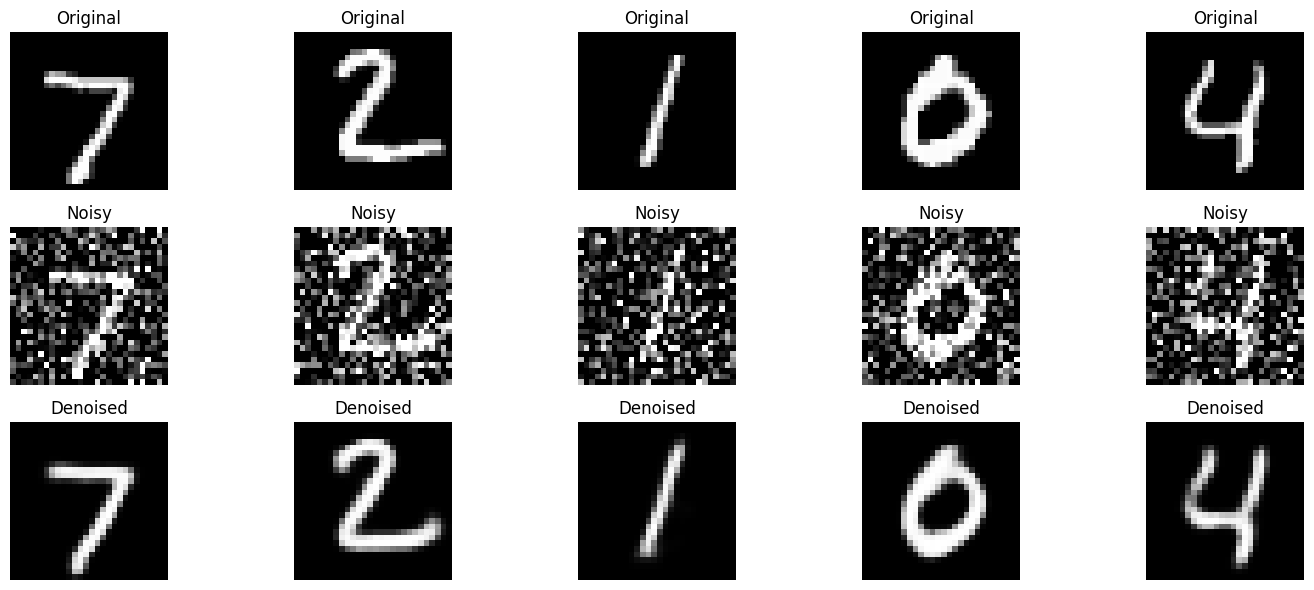

In [14]:
n=5
plt.figure(figsize=(15,6))
for i in range(n):
  ax=plt.subplot(3,n,i+1)
  plt.imshow(x_test[i].reshape(28,28),cmap='gray')
  plt.title("Original")
  plt.axis('off')

  ax=plt.subplot(3,n,i+n+1)
  plt.imshow(x_test_noisy[i].reshape(28,28),cmap='gray')
  plt.title("Noisy")
  plt.axis('off')

  ax=plt.subplot(3,n,i+2*n+1)
  plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
  plt.title("Denoised")
  plt.axis('off')
plt.tight_layout()
plt.show()

## Additional Experiment: Noise Factor = 0.3

To study the effect of lower noise, the noise factor was reduced from **0.5** to **0.3**. The same Convolutional Autoencoder architecture was used, while the model was trained for **15 epochs** to observe the reconstruction performance.

In [15]:
noise_factor=0.3
x_train_noisy=x_train+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_train.shape)
x_test_noisy=x_test+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_test.shape)
x_train_noisy=np.clip(x_train_noisy,0.,1.)
x_test_noisy=np.clip(x_test_noisy,0.,1.)

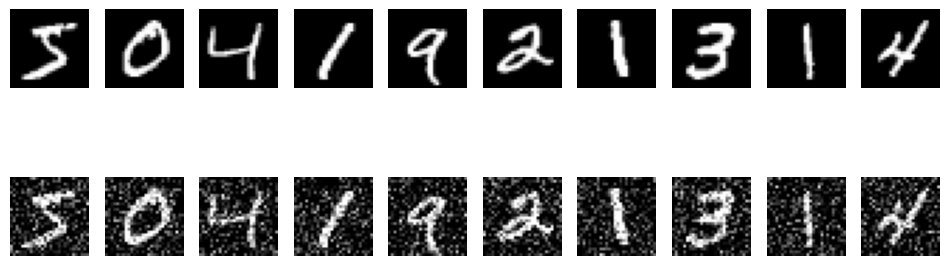

In [16]:
plt.figure(figsize=(12,4))
for i in range(10):
  ax=plt.subplot(2,10,i+1)
  plt.imshow(x_train[i].reshape(28,28),cmap='gray')
  plt.axis('off')

  ax=plt.subplot(2,10,i+11)
  plt.imshow(x_train_noisy[i].reshape(28,28),cmap='gray')
  plt.axis('off')
plt.show()

In [17]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

In [18]:
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 185s 391ms/step - loss: 0.1275 - val_loss: 0.0893
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 374ms/step - loss: 0.0872 - val_loss: 0.0847
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 175s 373ms/step - loss: 0.0837 - val_loss: 0.0818
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 372ms/step - loss: 0.0819 - val_loss: 0.0805
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 178s 380ms/step - loss: 0.0807 - val_loss: 0.0797
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 375ms/step - loss: 0.0799 - val_loss: 0.0788
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 374ms/step - loss: 0.0792 - val_loss: 0.0785
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 374ms/step - loss: 0.0787 - val_loss: 0.0780
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 175s 374ms/step - loss: 0.0783 - val_loss: 0.0776
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 179s 382ms/step - loss: 0.0779 - val_loss: 0.0773
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 378ms/step - loss: 0.0776 - val_loss: 0.0771
Epoch 12

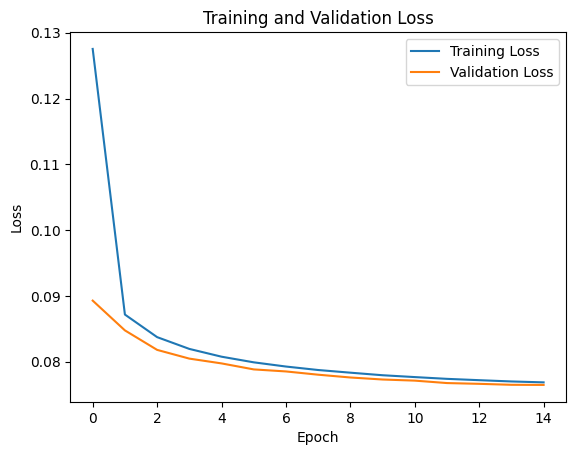

In [20]:
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [21]:
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

Final Training Loss: 0.07684118300676346
Final Validation Loss: 0.07645294815301895


In [22]:
decoded_imgs=autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step


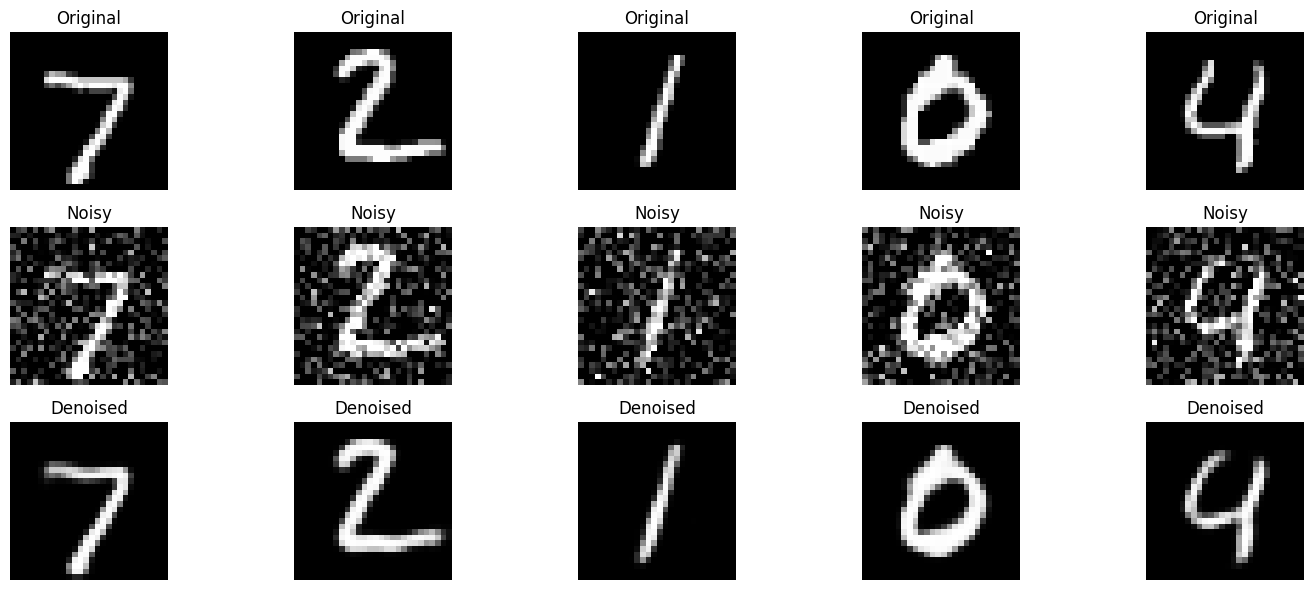

In [23]:
n=5
plt.figure(figsize=(15,6))
for i in range(n):
  ax=plt.subplot(3,n,i+1)
  plt.imshow(x_test[i].reshape(28,28),cmap='gray')
  plt.title("Original")
  plt.axis('off')

  ax=plt.subplot(3,n,i+n+1)
  plt.imshow(x_test_noisy[i].reshape(28,28),cmap='gray')
  plt.title("Noisy")
  plt.axis('off')

  ax=plt.subplot(3,n,i+2*n+1)
  plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
  plt.title("Denoised")
  plt.axis('off')
plt.tight_layout()
plt.show()

# Observations

- The autoencoder was able to remove most of the Gaussian noise from the images.
- Reducing the noise factor from **0.5** to **0.3** produced cleaner reconstructed images.
- The training and validation loss decreased during training, showing that the model learned the denoising task effectively.
- Some images still appear slightly blurred, but the digit shapes remain clear.

# Conclusion

A Convolutional Autoencoder was successfully implemented for image denoising using the MNIST dataset. The model reconstructed cleaner images from noisy inputs and showed good performance through decreasing loss values. The additional experiment with a lower noise factor demonstrated that less noise results in better image reconstruction.